# Analysis

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("data/main_data.csv")

C:\Users\cyril\AppData\Local\Temp\ipykernel_9124\1019944755.py:1: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("data/main_data.csv")


In [4]:
df.shape

(6758125, 26)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6758125 entries, 0 to 6758124
Data columns (total 26 columns):
 #   Column                Dtype  
---  ------                -----  
 0   SalesID               int64  
 1   SalesDate             object 
 2   Quantity              int64  
 3   Discount              float64
 4   TotalPrice            float64
 5   TransactionNumber     object 
 6   ProductName           object 
 7   ProductPrice          float64
 8   CategoryID            int64  
 9   Class                 object 
 10  ProductCategory       object 
 11  SalesPersonFirstName  object 
 12  SalesPersonLastName   object 
 13  CustomerFirstName     object 
 14  CustomerLastName      object 
 15  CustomerAddress       object 
 16  CustomerCityID        int64  
 17  CustomerCity          object 
 18  CustomerZipcode       int64  
 19  CustomerCountryID     int64  
 20  CustomerCountry       object 
 21  NetMargin             float64
 22  CountryID             int64  
 23  CityID 

In [6]:
df['SalesDate'] = pd.to_datetime(df['SalesDate'], errors='coerce')

In [7]:
df = df.sample(frac=0.01, random_state=42) 
df.shape

(67581, 26)

In [8]:
df = df.drop(columns=["CategoryID", "CustomerCityID", "CityID", "CountryID", "CustomerCountryID", "CountryCode"]) 

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67581 entries, 3390544 to 1450923
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   SalesID               67581 non-null  int64         
 1   SalesDate             66895 non-null  datetime64[ns]
 2   Quantity              67581 non-null  int64         
 3   Discount              67581 non-null  float64       
 4   TotalPrice            67581 non-null  float64       
 5   TransactionNumber     67581 non-null  object        
 6   ProductName           67581 non-null  object        
 7   ProductPrice          67581 non-null  float64       
 8   Class                 67581 non-null  object        
 9   ProductCategory       67581 non-null  object        
 10  SalesPersonFirstName  67581 non-null  object        
 11  SalesPersonLastName   67581 non-null  object        
 12  CustomerFirstName     67581 non-null  object        
 13  CustomerLastN

In [11]:
df.isna().sum()

SalesID                   0
SalesDate               686
Quantity                  0
Discount                  0
TotalPrice                0
TransactionNumber         0
ProductName               0
ProductPrice              0
Class                     0
ProductCategory           0
SalesPersonFirstName      0
SalesPersonLastName       0
CustomerFirstName         0
CustomerLastName          0
CustomerAddress           0
CustomerCity              0
CustomerZipcode           0
CustomerCountry           0
NetMargin                 0
CountryName               0
dtype: int64

In [12]:
numerical_features = df.select_dtypes(include=['float64']).columns.tolist()
categorical_features = df.select_dtypes(include=['int', 'object']).columns.tolist()
categorical_features.append('SalesDate')
target  = 'TotalPrice'

# Vizualising Data Distibutions, Correlations and interactions between variables

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import LabelEncoder
import math

sns.set_style("whitegrid")
plt.rcParams.update({
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "axes.labelweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11
})

def plot_categorical(data, categorical_features):
    n = len(categorical_features)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, feature in enumerate(categorical_features):
        top_10 = data[feature].value_counts().nlargest(10).index
        filtered_data = data[data[feature].isin(top_10)]

        sns.countplot(data=filtered_data, x=feature, ax=axes[i],
                      order=top_10, edgecolor="black", linewidth=1.5,
                      alpha=0.7, color="#C04343")
        axes[i].set_title(f"Top 10: {feature}")
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def plot_distribution(data, numerical_features):
    n = len(numerical_features)
    cols = 3
    rows = math.ceil(n / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(14, 4 * rows))
    axes = axes.flatten()

    for i, feature in enumerate(numerical_features):
        sns.histplot(data[feature], kde=True, bins=30, color="#338AFF", ax=axes[i], alpha=0.7)
        axes[i].set_title(f"Distribution of {feature}")
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel("Frequency")
        axes[i].tick_params(axis='x', rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()


def correlation(data, categorical_features):
    for c in categorical_features:
        data[c] = LabelEncoder().fit_transform(data[c])

    corr_matrix = data.corr(numeric_only=True)

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, cmap="magma", fmt=".2f", linewidths=1,
                edgecolor="black", linecolor="black", square=True,
                cbar_kws={"orientation": "horizontal", "shrink": 0.75})
    plt.title("Correlation Matrix")
    plt.tight_layout()
    plt.show()


def plot_pie_chart(data, column):
    counts = data[column].value_counts()
    explode_values = [0.1 if i == 0 else 0 for i in range(len(counts))]

    plt.figure(figsize=(5, 5))
    plt.pie(counts, labels=counts.index, autopct="%1.1f%%",
            colors=["#C04343", "#338AFF"], explode=explode_values,
            startangle=90, shadow=True, textprops={'color': 'black'})
    plt.title(f"Proportion of {column}")
    plt.tight_layout()
    plt.show()


def plot_boxplot(data, numerical_column, hue_column):
    n_categories = data[hue_column].nunique()
    width = max(6, n_categories * 1.2)
    height = 5 

    plt.figure(figsize=(width, height))
    sns.boxplot(x=hue_column, y=numerical_column, data=data)
    plt.title(f"Boxplot of {numerical_column} by {hue_column}")
    plt.xlabel(hue_column)
    plt.ylabel(numerical_column)
    plt.xticks(rotation=45) 
    plt.tight_layout()
    plt.show()

    
def plot_scatter(data, x_col, y_col):
    plt.figure(figsize=(6, 5))
    sns.scatterplot(data=data, x=x_col, y=y_col, color="#338AFF")
    plt.title(f"Scatter Plot: {y_col} vs {x_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.tight_layout()
    plt.show()


def plot_categorical_heatmap(data, cat1, cat2):
    cross_tab = pd.crosstab(data[cat1], data[cat2])
    plt.figure(figsize=(max(6, len(cross_tab.columns) * 0.8), max(5, len(cross_tab.index) * 0.5)))
    sns.heatmap(cross_tab, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Frequency Heatmap: {cat1} vs {cat2}")
    plt.xlabel(cat2)
    plt.ylabel(cat1)
    plt.tight_layout()
    plt.show()


def plot_pairplot(data, numerical_features, hue_column):
    sns.pairplot(data, vars=numerical_features, hue=hue_column, diag_kind="kde",
                 plot_kws={"alpha": 0.5})
    plt.tight_layout()
    plt.show()


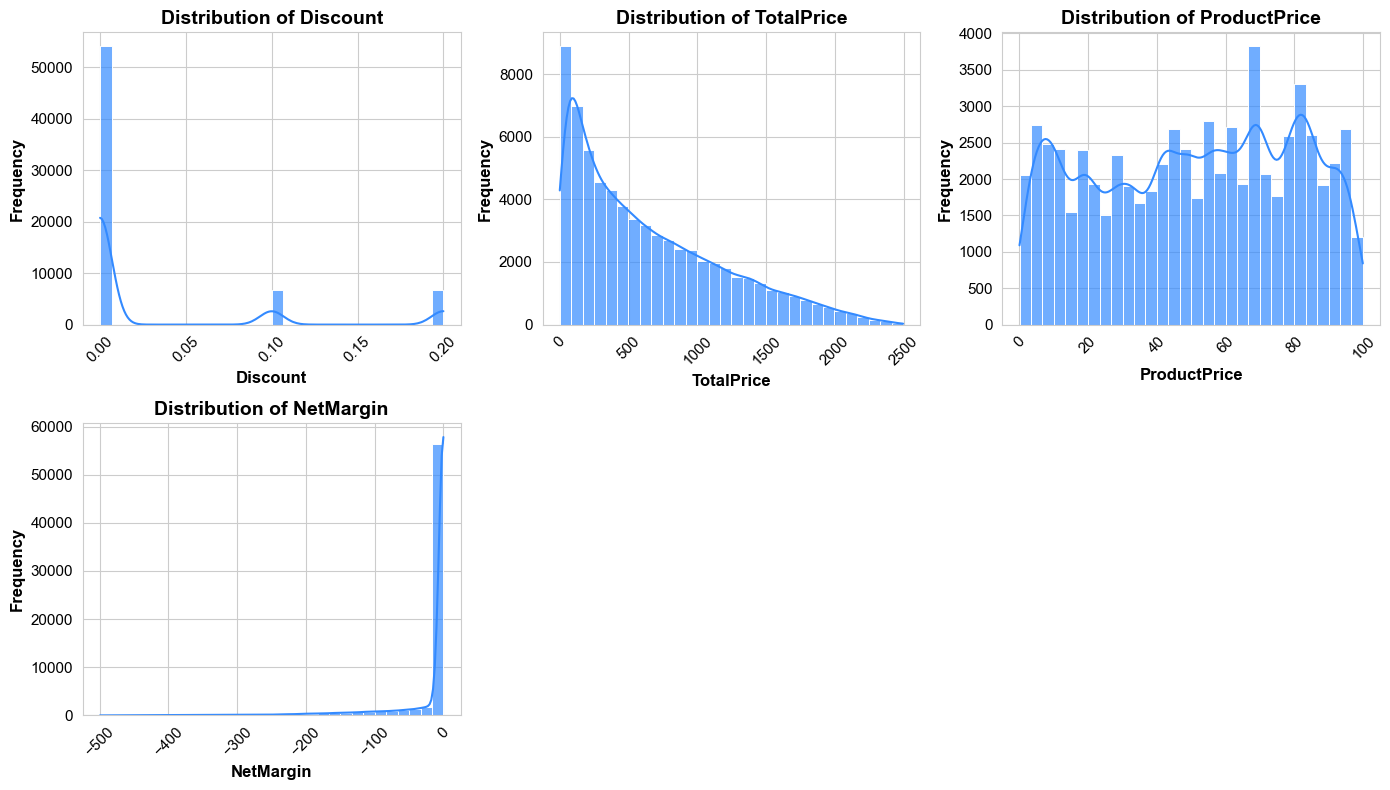

In [14]:
plot_distribution(df, numerical_features)

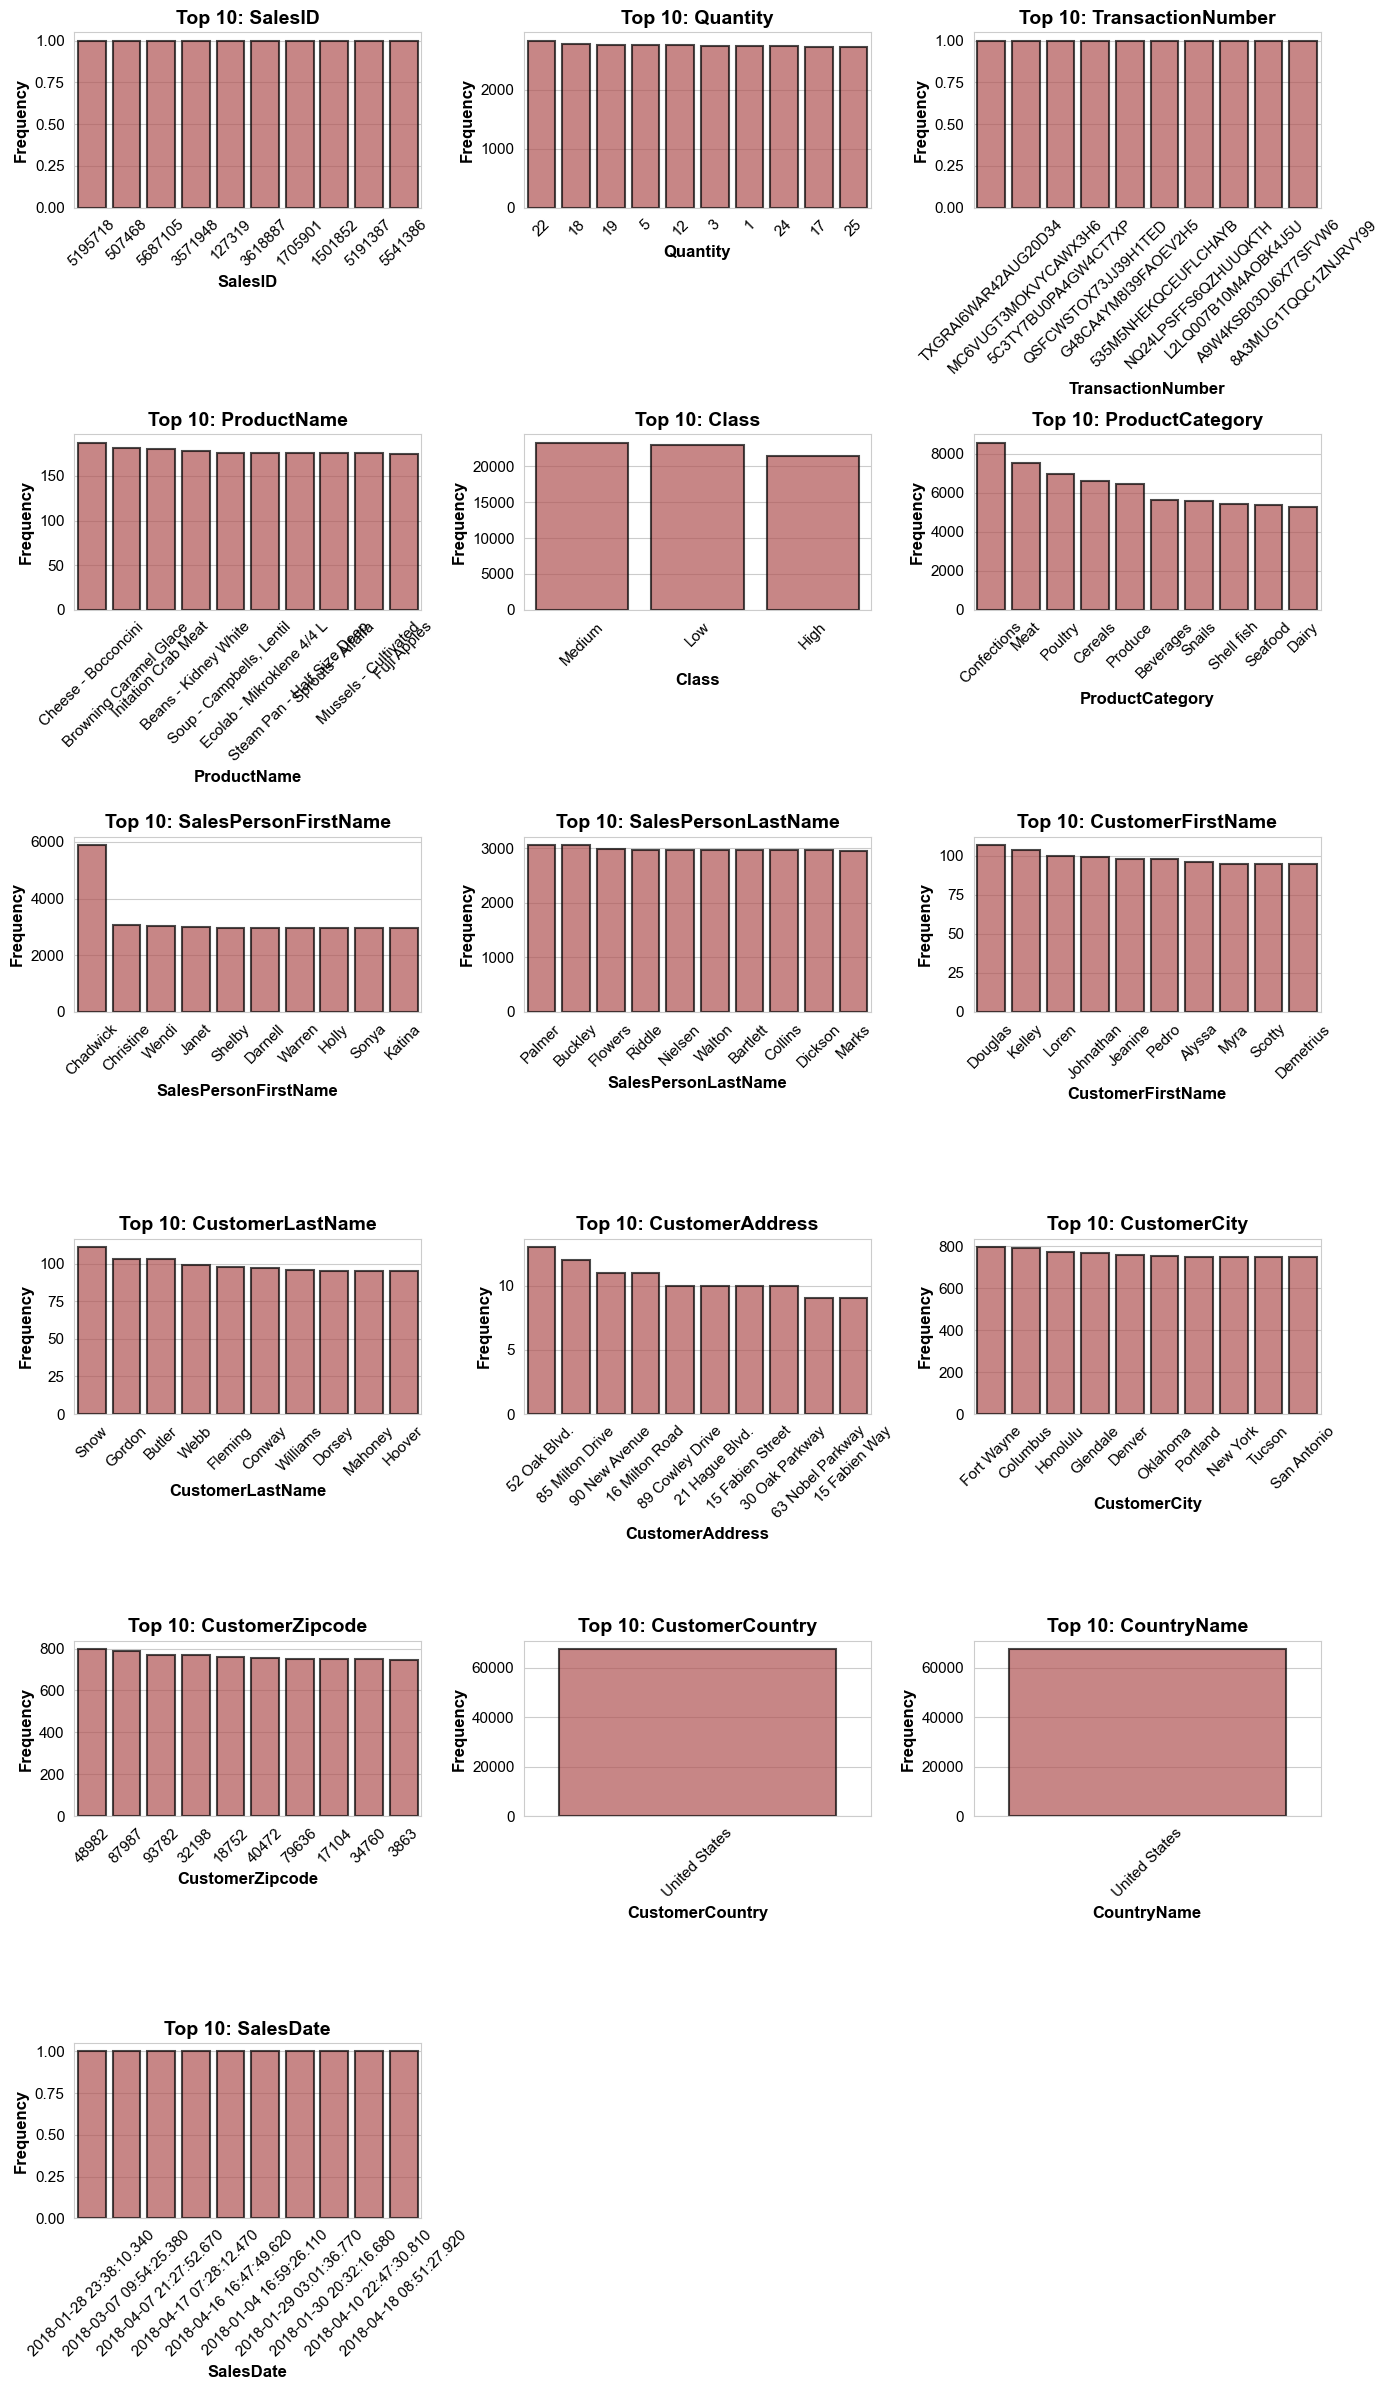

In [15]:
plot_categorical(df, categorical_features)

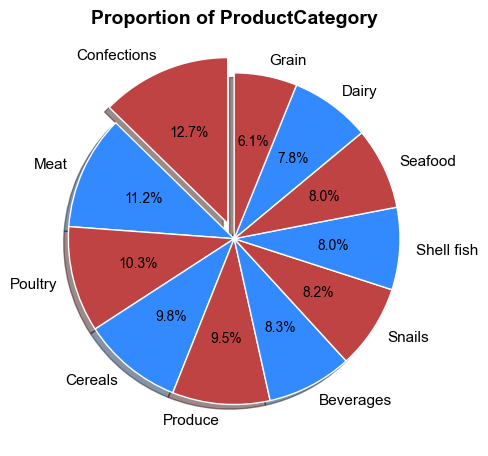

In [37]:
plot_pie_chart(df, 'ProductCategory')

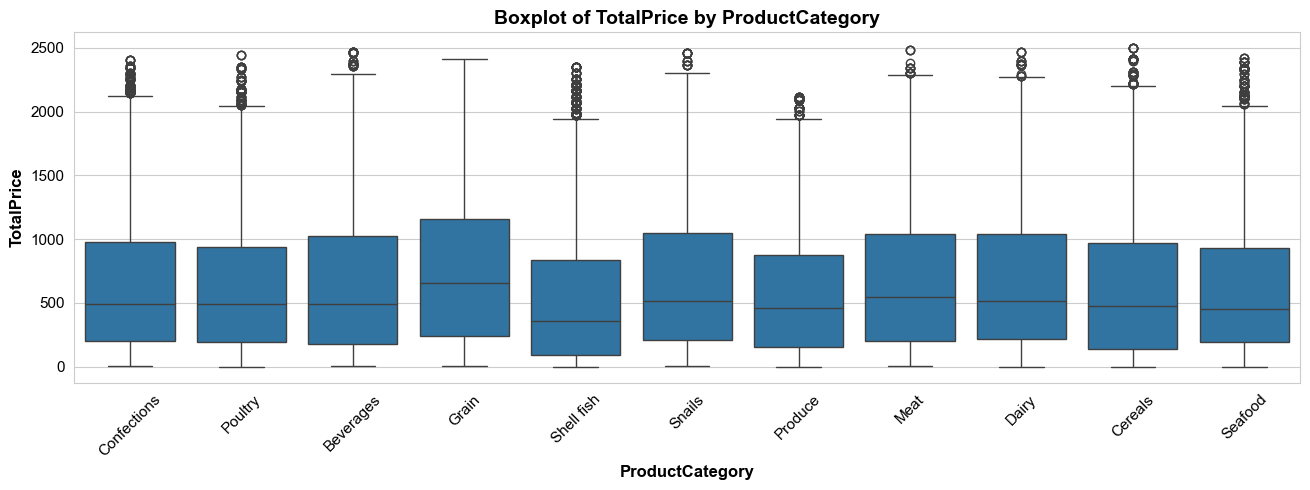

In [16]:
plot_boxplot(df, 'TotalPrice', 'ProductCategory')

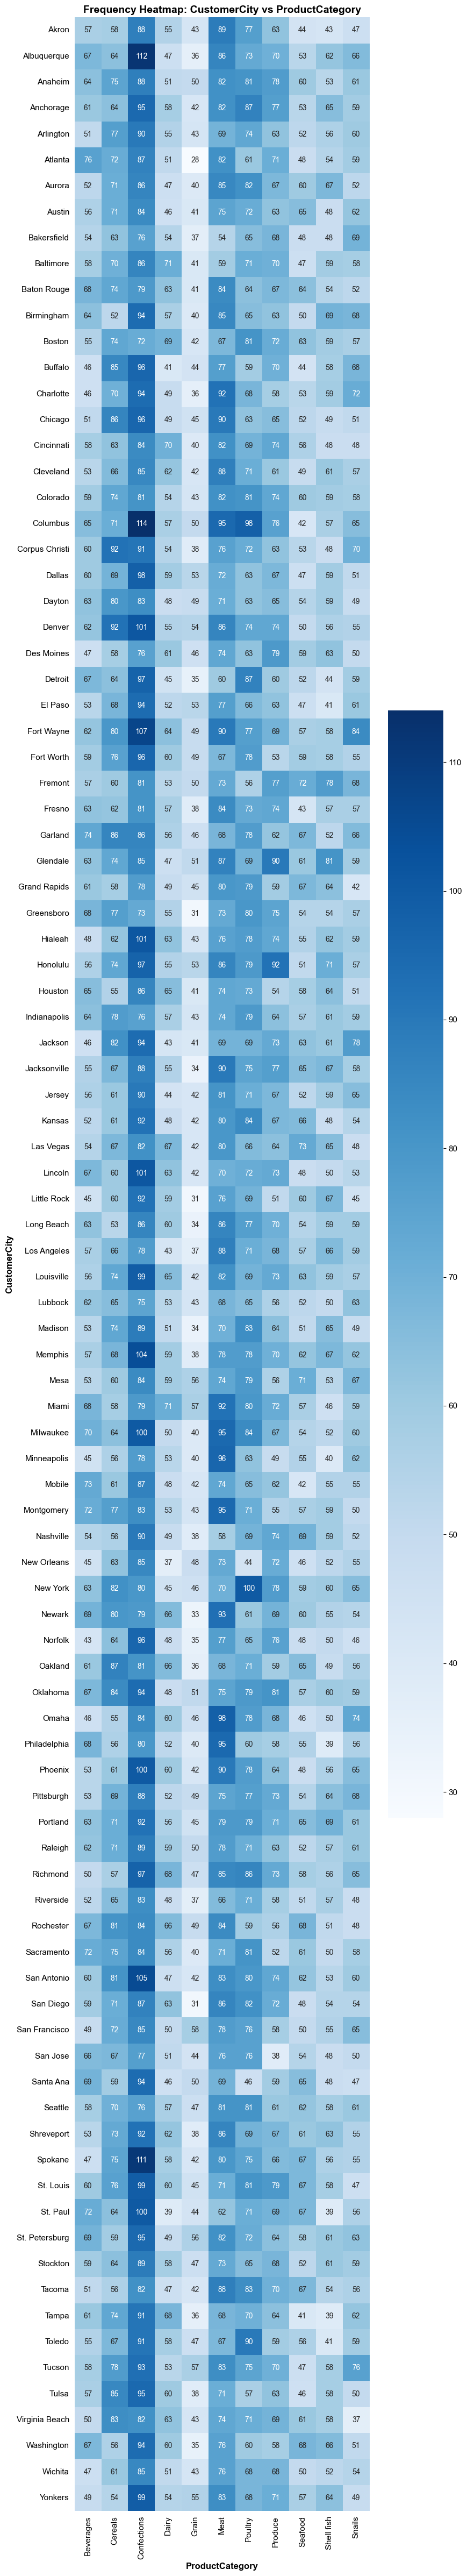

In [34]:
plot_categorical_heatmap(df, 'CustomerCity', 'ProductCategory')

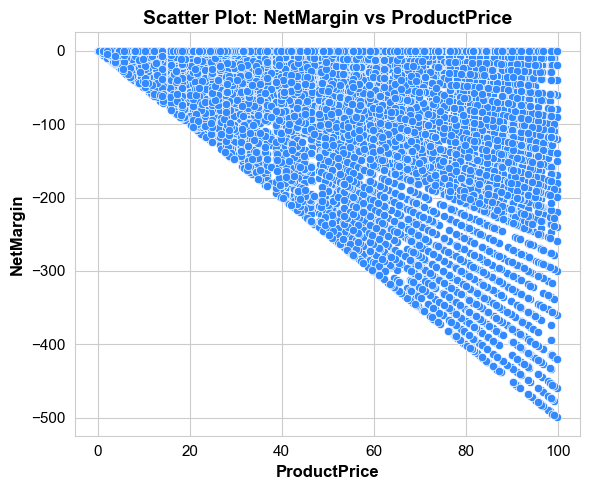

In [36]:
plot_scatter(df, 'ProductPrice', 'NetMargin')

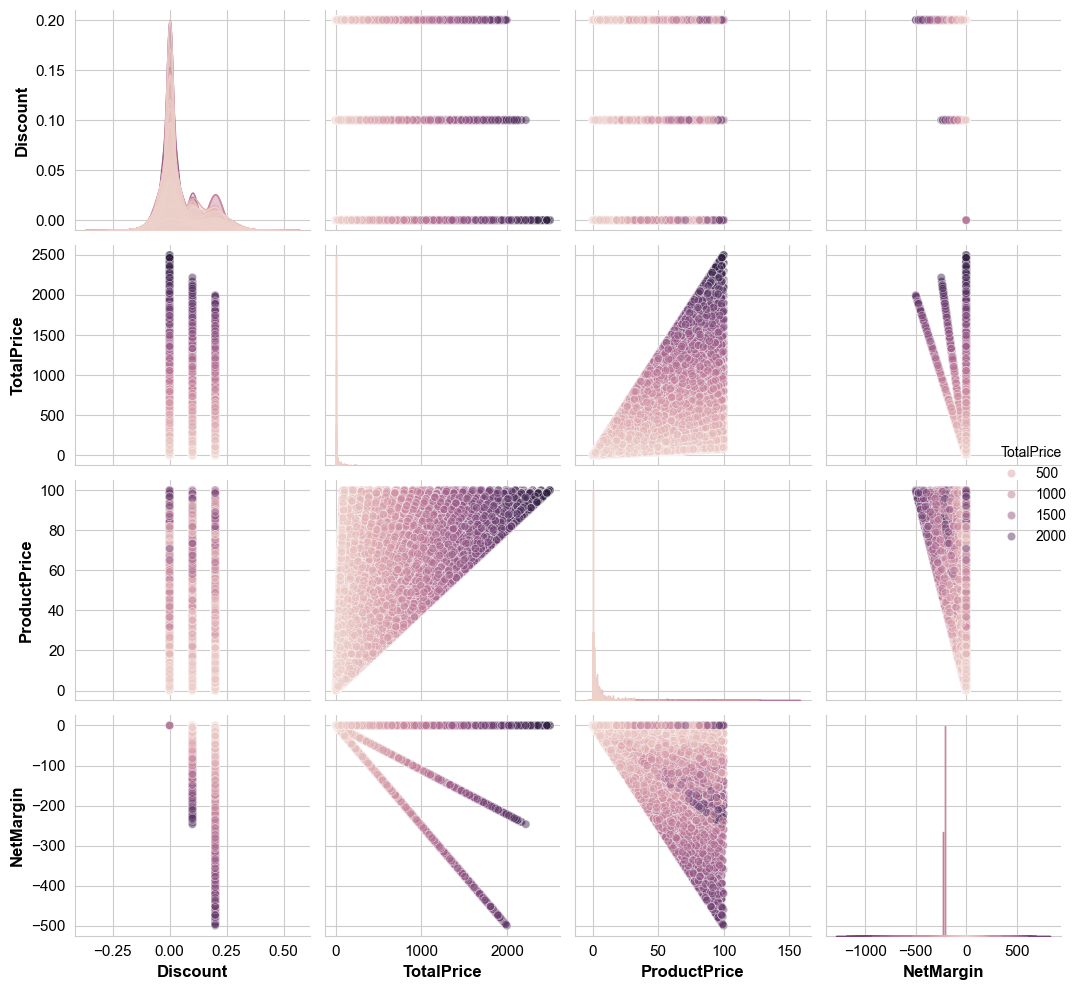

In [ ]:
plot_pairplot(df, numerical_features, target)

# Data preparation for Machine Learning

In [18]:
cols_to_drop = ['ProductPrice', 'Quantity']
features_selected = df.drop(columns=cols_to_drop).copy()
numerical_features = [col for col in numerical_features if col not in cols_to_drop]
categorical_features = [col for col in categorical_features if col not in cols_to_drop]

In [19]:
df_copy = features_selected.copy()

q33 = df_copy[target].quantile(0.33)
q66 = df_copy[target].quantile(0.66)

bin_edges = [-float('inf'), q33, q66, float('inf')]
bin_edges = sorted(set(bin_edges))

bin_labels = ["low", "medium", "high"][:len(bin_edges) - 1]

df_copy[target + "_category"] = pd.cut(
    df_copy[target],
    bins=bin_edges,
    labels=bin_labels
)

df_copy.drop(columns=[target], inplace=True)
df_copy.rename(columns={target + "_category": target}, inplace=True)

if target in numerical_features:
    numerical_features.remove(target)
    categorical_features.append(target)

In [20]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 67581 entries, 3390544 to 1450923
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   SalesID               67581 non-null  int64         
 1   SalesDate             66895 non-null  datetime64[ns]
 2   Discount              67581 non-null  float64       
 3   TransactionNumber     67581 non-null  object        
 4   ProductName           67581 non-null  object        
 5   Class                 67581 non-null  object        
 6   ProductCategory       67581 non-null  object        
 7   SalesPersonFirstName  67581 non-null  object        
 8   SalesPersonLastName   67581 non-null  object        
 9   CustomerFirstName     67581 non-null  object        
 10  CustomerLastName      67581 non-null  object        
 11  CustomerAddress       67581 non-null  object        
 12  CustomerCity          67581 non-null  object        
 13  CustomerZipco

In [21]:
from sklearn.preprocessing import  LabelEncoder, StandardScaler

def prepare_data(df, numerical_features, categorical_features):
    data = df.copy()
    scaler = StandardScaler()
    data[numerical_features] = scaler.fit_transform(data[numerical_features])
    for c in categorical_features:
        label_encoder = LabelEncoder()
        data[c] = label_encoder.fit_transform(data[c])

    return data

In [22]:
normalized_data = prepare_data(df_copy, numerical_features, categorical_features)

In [23]:
normalized_data

,SalesID,SalesDate,Discount,TransactionNumber,ProductName,Class,ProductCategory,SalesPersonFirstName,SalesPersonLastName,CustomerFirstName,CustomerLastName,CustomerAddress,CustomerCity,CustomerZipcode,CustomerCountry,NetMargin,CountryName,TotalPrice
3390544,5145,34010,-0.468881,41918,258,0,2,13,3,818,421,21285,37,93,0,0.342068,0,1
5025189,56911,50258,-0.468881,9926,185,2,2,20,0,560,545,8362,2,23,0,0.342068,0,1
5513297,35745,55146,-0.468881,50226,391,0,6,1,22,696,457,21035,19,82,0,0.342068,0,2
5481514,1301,54840,2.651035,30143,166,2,0,19,15,724,170,25730,57,8,0,0.000197,0,1
191596,36210,1992,-0.468881,9468,167,0,0,11,9,202,438,7066,21,20,0,0.342068,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2232844,465,22375,-0.468881,50511,417,1,3,15,4,816,502,22343,12,53,0,0.342068,0,0
3326701,8769,33369,-0.468881,60733,360,1,1,21,2,829,435,33218,66,16,0,0.342068,0,1
25843,29641,274,-0.468881,2190,216,1,9,17,19,584,846,37301,69,71,0,0.342068,0,1
1430578,18562,14418,-0.468881,15030,311,0,8,0,16,68,388,4597,76,80,0,0.342068,0,2


In [24]:
from sklearn.model_selection import train_test_split
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
import xgboost as xgb
import json
import numpy as np

class ClassificationModel:

    def __init__(self, dataframe, target, epochs =100):
        self.data = dataframe.copy()
        self.X = self.data.drop(columns=target)
        self.y = self.data[target]

        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(
            self.X, self.y, test_size=0.2, random_state=42
        )

        self.num_classes = len(np.unique(self.y))

        self.feature_names = list(self.X.columns)
        

        self.model = xgb.XGBClassifier(
            objective="multi:softprob",
            eval_metric="mlogloss",
            num_class=self.num_classes,
            learning_rate=0.09,
            n_estimators=epochs,
            max_depth=15,
            min_child_weight=3,
            gamma=1,
            subsample=0.8,
            colsample_bytree=0.8,
            reg_alpha=0.2,
            reg_lambda=1.2,
            tree_method="hist",
            random_state=42,
        )

    def simple_train(self):
        eval_set = [(self.X_train, self.y_train), (self.X_test, self.y_test)]
        self.model.fit(self.X_train, self.y_train, eval_set=eval_set,verbose=True)

    def evaluate(self):
        y_proba = self.model.predict_proba(self.X_test)
        y_pred = y_proba.argmax(axis=1)
        confidence_scores = np.max(y_proba, axis=1)

        acc = accuracy_score(self.y_test, y_pred)
        print(f"Model Accuracy: {acc:.4f}")
        print("\nClassification Report:\n", classification_report(self.y_test, y_pred))

        results = pd.DataFrame({
            "True Label": self.y_test,
            "Predicted Label": y_pred,
            "Confidence": confidence_scores
        }).reset_index(drop=True)

        return results

    def feature_importance(self):
        importance = self.model.feature_importances_
        features = self.X.columns
       
        fi = pd.DataFrame({"Feature": features, "Importance": importance}).sort_values(by="Importance", ascending=False)
        plt.figure(figsize=(10, 6))
        sns.barplot(x="Importance", y="Feature", data=fi, palette="viridis", hue="Feature", dodge=False)
        plt.title("Feature Importance - Booster" if hasattr(self, "booster") else "Feature Importance - Model")
        plt.legend([], [], frameon=False)
        plt.tight_layout()
        plt.show()
        return fi
    

    def plot_training_loss(self):
        evals_result = self.model.evals_result()
        train_loss = evals_result['validation_0']['mlogloss']
        val_loss = evals_result['validation_0' if len(evals_result) == 1 else 'validation_1']['mlogloss']

        plt.figure(figsize=(10, 6))
        plt.plot(train_loss, label='Training Loss', marker='o')
        if train_loss != val_loss:  
            plt.plot(val_loss, label='Validation Loss', marker='x')
        plt.xlabel('Boosting Rounds')
        plt.ylabel('Log Loss')
        plt.title('Training vs Validation Log Loss')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()

       
    def plot_roc_curve(self):
        y_test_bin = label_binarize(self.y_test, classes=np.arange(self.num_classes))
        y_score = self.model.predict_proba(self.X_test)
        
        fpr = dict()
        tpr = dict()
        roc_auc = dict()

        plt.figure(figsize=(10, 7))
        for i in range(self.num_classes):
            fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            roc_auc[i] = auc(fpr[i], tpr[i])
            plt.plot(fpr[i], tpr[i], lw=2, label=f"Class {i} (AUC = {roc_auc[i]:.2f})")

        plt.plot([0, 1], [0, 1], 'k--', lw=2)
        plt.xlim([-0.01, 1.01])
        plt.ylim([-0.01, 1.01])
        plt.xlabel("False Positive Rate")
        plt.ylabel("True Positive Rate")
        plt.title("ROC Curve")
        plt.legend(loc="lower right")
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    def save_model(self, path="XGBOOST_Model/xgboost_model.json", features_path="XGBOOST_Model/feature_names.json"):
        
        self.model.save_model(path)
        print(f"Booster model saved as: {path}")

        with open(features_path, "w") as f:
            json.dump(self.feature_names, f)
        print(f"Feature names saved as: {features_path}")

In [25]:
xgboost_simple_model = ClassificationModel(normalized_data, target, epochs=50)
xgboost_simple_model.simple_train()  
xgboost_simple_model_preds = xgboost_simple_model.evaluate()

[0]	validation_0-mlogloss:1.05366	validation_1-mlogloss:1.06049
[1]	validation_0-mlogloss:1.01482	validation_1-mlogloss:1.03185
[2]	validation_0-mlogloss:0.97589	validation_1-mlogloss:1.00015
[3]	validation_0-mlogloss:0.94181	validation_1-mlogloss:0.97084
[4]	validation_0-mlogloss:0.90687	validation_1-mlogloss:0.94084
[5]	validation_0-mlogloss:0.87896	validation_1-mlogloss:0.92067
[6]	validation_0-mlogloss:0.85157	validation_1-mlogloss:0.90193
[7]	validation_0-mlogloss:0.82329	validation_1-mlogloss:0.87848
[8]	validation_0-mlogloss:0.79971	validation_1-mlogloss:0.86081
[9]	validation_0-mlogloss:0.78379	validation_1-mlogloss:0.85101
[10]	validation_0-mlogloss:0.76240	validation_1-mlogloss:0.83468
[11]	validation_0-mlogloss:0.74520	validation_1-mlogloss:0.82436
[12]	validation_0-mlogloss:0.73313	validation_1-mlogloss:0.81670
[13]	validation_0-mlogloss:0.71753	validation_1-mlogloss:0.80391
[14]	validation_0-mlogloss:0.70681	validation_1-mlogloss:0.79841
[15]	validation_0-mlogloss:0.69271	

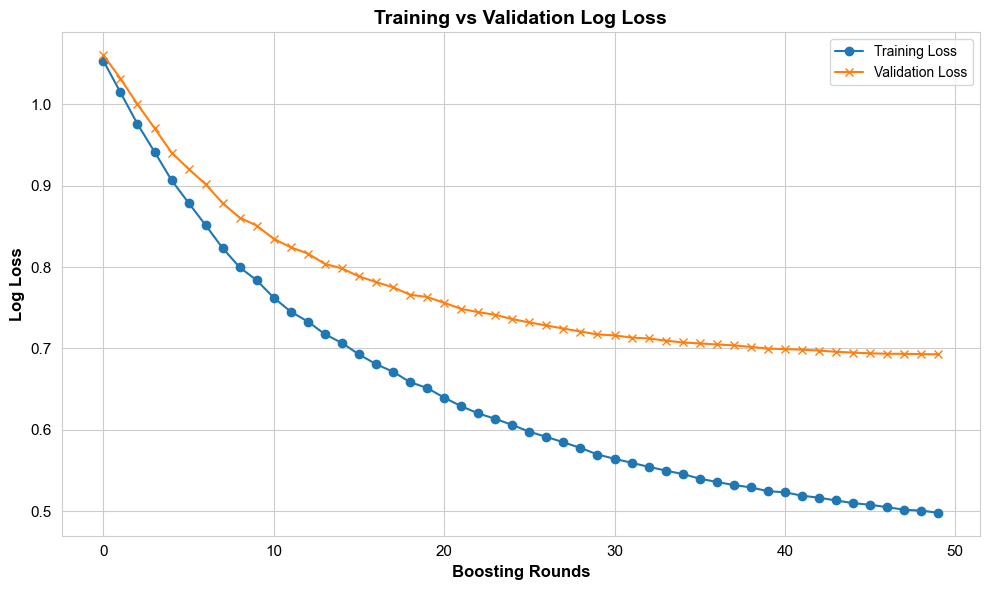

In [26]:
xgboost_simple_model.plot_training_loss()

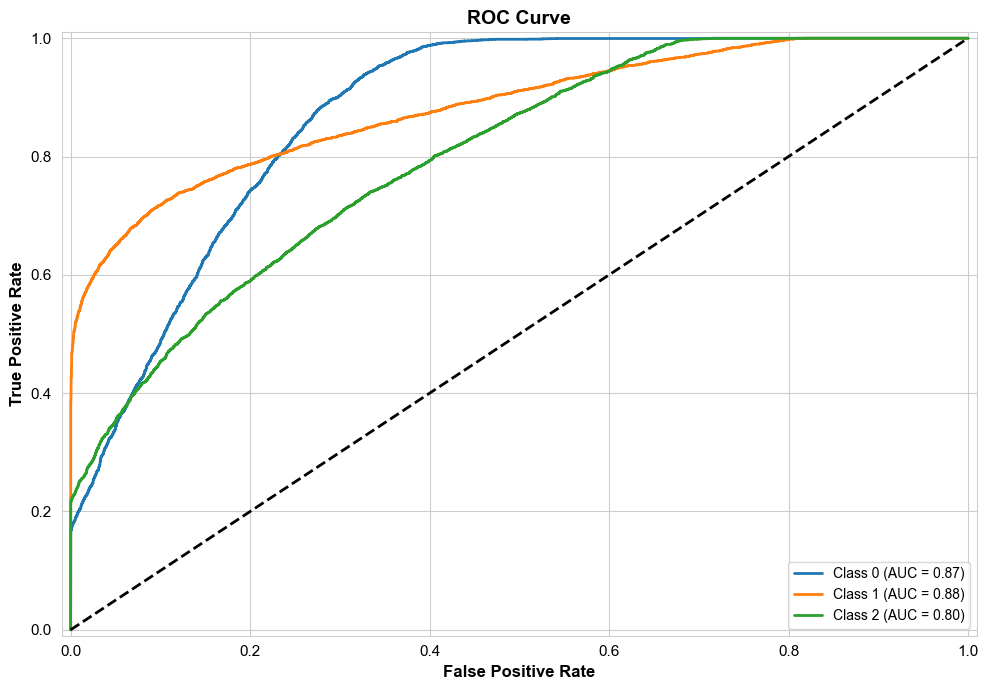

In [27]:
xgboost_simple_model.plot_roc_curve()

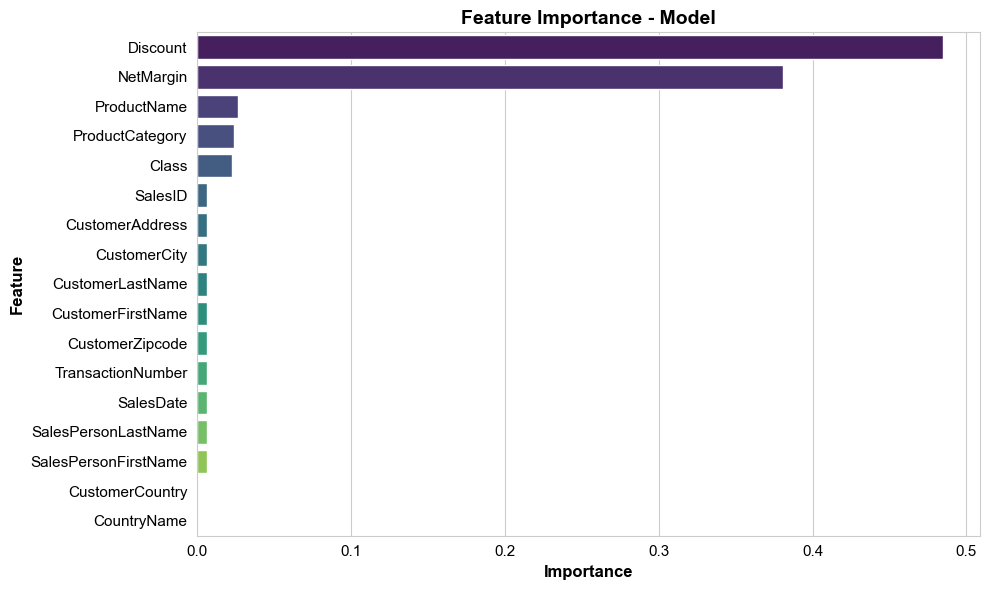

,Feature,Importance
2,Discount,0.484619
15,NetMargin,0.380865
4,ProductName,0.026630
6,ProductCategory,0.024037
5,Class,0.022190
0,SalesID,0.006287
11,CustomerAddress,0.006253
12,CustomerCity,0.006235
10,CustomerLastName,0.006203
9,CustomerFirstName,0.006199


In [28]:
xgboost_simple_model.feature_importance()

# Time series Analysis

In [43]:
def get_date_range(data,  date_column):

    start_date = data[date_column].min()
    end_date = data[date_column].max()

    return start_date, end_date


In [44]:
date_column = 'SalesDate'
start_date, end_date = get_date_range(df, date_column)
print(start_date, end_date)

2018-01-01 00:00:25.190000 2018-05-09 23:58:24.030000


In [49]:
df_time_series = features_selected.copy()

In [50]:
df_time_series[date_column] = pd.to_datetime(df_time_series[date_column])
df_time_series.set_index(date_column, inplace=True)
df_time_series.sort_index(inplace=True)
df_time_series

,SalesID,Discount,TotalPrice,TransactionNumber,ProductName,Class,ProductCategory,SalesPersonFirstName,SalesPersonLastName,CustomerFirstName,CustomerLastName,CustomerAddress,CustomerCity,CustomerZipcode,CustomerCountry,NetMargin,CountryName
SalesDate,,,,,,,,,,,,,,,,,
2018-01-01 00:00:25.190,953067,0.0,1328.17600,LPD5ASECS9C092OUVC7B,"Soup - Campbells, Lentil",Medium,Dairy,Desiree,Stuart,Harry,Watkins,116 Green Milton Road,St. Paul,77998,United States,0.00000,United States
2018-01-01 00:01:52.240,1277118,0.2,1452.60320,5KIAIO52JVCVJ16C5YA3,Bread Foccacia Whole,High,Poultry,Jean,Vang,Annette,Oliver,208 Rocky Fabien Street,Baton Rouge,21874,United States,-363.15080,United States
2018-01-01 00:04:52.670,2636372,0.1,8.42346,5E5BTXK4XDG8J5GX8PKG,Coffee - Irish Cream,Medium,Shell fish,Devon,Brewer,Derek,Murphy,98 Rocky Hague Avenue,Dayton,80563,United States,-0.93594,United States
2018-01-01 00:10:32.830,2693850,0.0,1285.07360,N2M8DR50M97JY7OKO0DS,"Nut - Pistachio, Shelled",Low,Meat,Julie,Dyer,Chandra,Bradley,705 Milton Avenue,Jacksonville,68274,United States,0.00000,United States
2018-01-01 00:11:37.820,3036590,0.0,386.05470,2Z0TN6L1E6D30GUBHDNG,"Pork - Back, Short Cut, Boneless",High,Snails,Katina,Marks,Ronnie,Maxwell,880 Rocky Oak Avenue,St. Paul,77998,United States,0.00000,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,5803069,0.0,172.41420,1IIP3VJG1XGNP9YS60AG,Sobe - Tropical Energy,High,Poultry,Devon,Brewer,Corey,Mckay,85 White Cowley St.,Austin,781,United States,0.00000,United States
NaT,5309128,0.0,920.87200,5AKX34FR0BS5WPBBV4AX,"Chestnuts - Whole,canned",Medium,Snails,Chadwick,Cook,Jonathan,Calderon,15 Milton Way,Greensboro,35659,United States,0.00000,United States
NaT,4085050,0.1,729.12060,U2CPXG09ICA53F2EJ9H8,Wine - Crozes Hermitage E.,Medium,Produce,Wendi,Buckley,Kristina,Campos,393 Rocky First St.,San Antonio,3863,United States,-81.01340,United States


In [51]:
a = pd.date_range(start=start_date, end=end_date, freq="D")
b = df_time_series.index 
diff_dates = a.difference(b) 

td = pd.Timedelta(1, "d") 
for date in diff_dates:
    prev_val = [date-td] 
    df_time_series
[date] = prev_val 

df_time_series.sort_index(inplace=True)

df_time_series.freq = "D"

In [ ]:
df_time_series

,SalesID,Discount,TotalPrice,TransactionNumber,ProductName,Class,ProductCategory,SalesPersonFirstName,SalesPersonLastName,CustomerFirstName,CustomerLastName,CustomerAddress,CustomerCity,CustomerZipcode,CustomerCountry,NetMargin,CountryName
SalesDate,,,,,,,,,,,,,,,,,
2018-01-01 00:00:25.190,953067,0.0,1328.17600,LPD5ASECS9C092OUVC7B,"Soup - Campbells, Lentil",Medium,Dairy,Desiree,Stuart,Harry,Watkins,116 Green Milton Road,St. Paul,77998,United States,0.00000,United States
2018-01-01 00:01:52.240,1277118,0.2,1452.60320,5KIAIO52JVCVJ16C5YA3,Bread Foccacia Whole,High,Poultry,Jean,Vang,Annette,Oliver,208 Rocky Fabien Street,Baton Rouge,21874,United States,-363.15080,United States
2018-01-01 00:04:52.670,2636372,0.1,8.42346,5E5BTXK4XDG8J5GX8PKG,Coffee - Irish Cream,Medium,Shell fish,Devon,Brewer,Derek,Murphy,98 Rocky Hague Avenue,Dayton,80563,United States,-0.93594,United States
2018-01-01 00:10:32.830,2693850,0.0,1285.07360,N2M8DR50M97JY7OKO0DS,"Nut - Pistachio, Shelled",Low,Meat,Julie,Dyer,Chandra,Bradley,705 Milton Avenue,Jacksonville,68274,United States,0.00000,United States
2018-01-01 00:11:37.820,3036590,0.0,386.05470,2Z0TN6L1E6D30GUBHDNG,"Pork - Back, Short Cut, Boneless",High,Snails,Katina,Marks,Ronnie,Maxwell,880 Rocky Oak Avenue,St. Paul,77998,United States,0.00000,United States
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,5803069,0.0,172.41420,1IIP3VJG1XGNP9YS60AG,Sobe - Tropical Energy,High,Poultry,Devon,Brewer,Corey,Mckay,85 White Cowley St.,Austin,781,United States,0.00000,United States
NaT,5309128,0.0,920.87200,5AKX34FR0BS5WPBBV4AX,"Chestnuts - Whole,canned",Medium,Snails,Chadwick,Cook,Jonathan,Calderon,15 Milton Way,Greensboro,35659,United States,0.00000,United States
NaT,4085050,0.1,729.12060,U2CPXG09ICA53F2EJ9H8,Wine - Crozes Hermitage E.,Medium,Produce,Wendi,Buckley,Kristina,Campos,393 Rocky First St.,San Antonio,3863,United States,-81.01340,United States


In [117]:
import random
random_city = random.choice(df_time_series['CustomerCity'].unique())
city_data = df_time_series[df_time_series['CustomerCity'] == random_city]
city_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 674 entries, 2018-01-01 12:34:15.680000 to NaT
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   SalesID               674 non-null    int64  
 1   Discount              674 non-null    float64
 2   TotalPrice            674 non-null    float64
 3   TransactionNumber     674 non-null    object 
 4   ProductName           674 non-null    object 
 5   Class                 674 non-null    object 
 6   ProductCategory       674 non-null    object 
 7   SalesPersonFirstName  674 non-null    object 
 8   SalesPersonLastName   674 non-null    object 
 9   CustomerFirstName     674 non-null    object 
 10  CustomerLastName      674 non-null    object 
 11  CustomerAddress       674 non-null    object 
 12  CustomerCity          674 non-null    object 
 13  CustomerZipcode       674 non-null    int64  
 14  CustomerCountry       674 non-null    object 


In [129]:
weekly_city_data = city_data.groupby(pd.Grouper(freq='W')).agg({
    'Discount': 'sum', 
    'TotalPrice': 'sum',
    'NetMargin': 'sum',
    'CustomerCity': 'last',
    'CustomerCountry': 'last',
    'CountryName': 'last',
    'CustomerZipcode': 'last',
    'SalesPersonFirstName': 'last',
    'SalesPersonLastName': 'last',
    'ProductCategory': 'last',
    'ProductName': 'last',
    'Class': 'last',
    'TransactionNumber': 'last',
    'CustomerFirstName': 'last',
    'CustomerLastName': 'last',
    'CustomerAddress': 'last',
}).reset_index()

weekly_city_data.set_index('SalesDate', inplace=True)

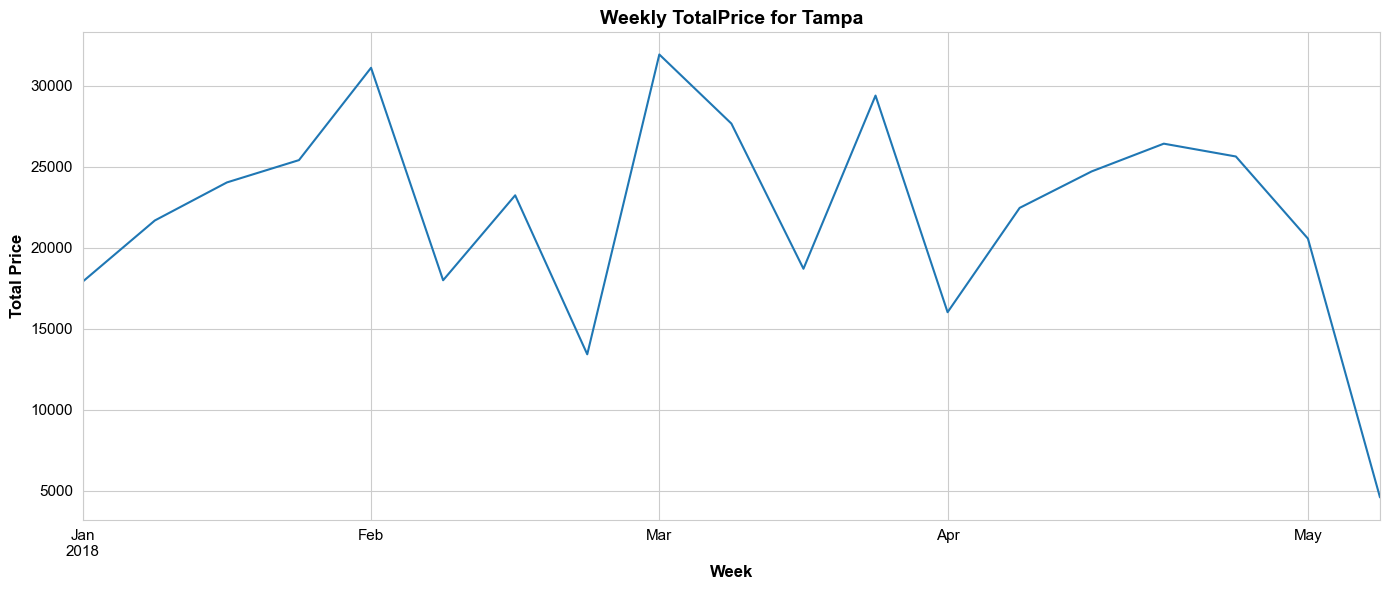

In [132]:
weekly_city_data['TotalPrice'].plot(figsize=(14, 6), title=f'Weekly TotalPrice for {random_city}')
plt.xlabel('Week')
plt.ylabel('Total Price')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
train_size = int(len(weekly_city_data) * 0.8)
train, test = weekly_city_data[:train_size], weekly_city_data[train_size:]

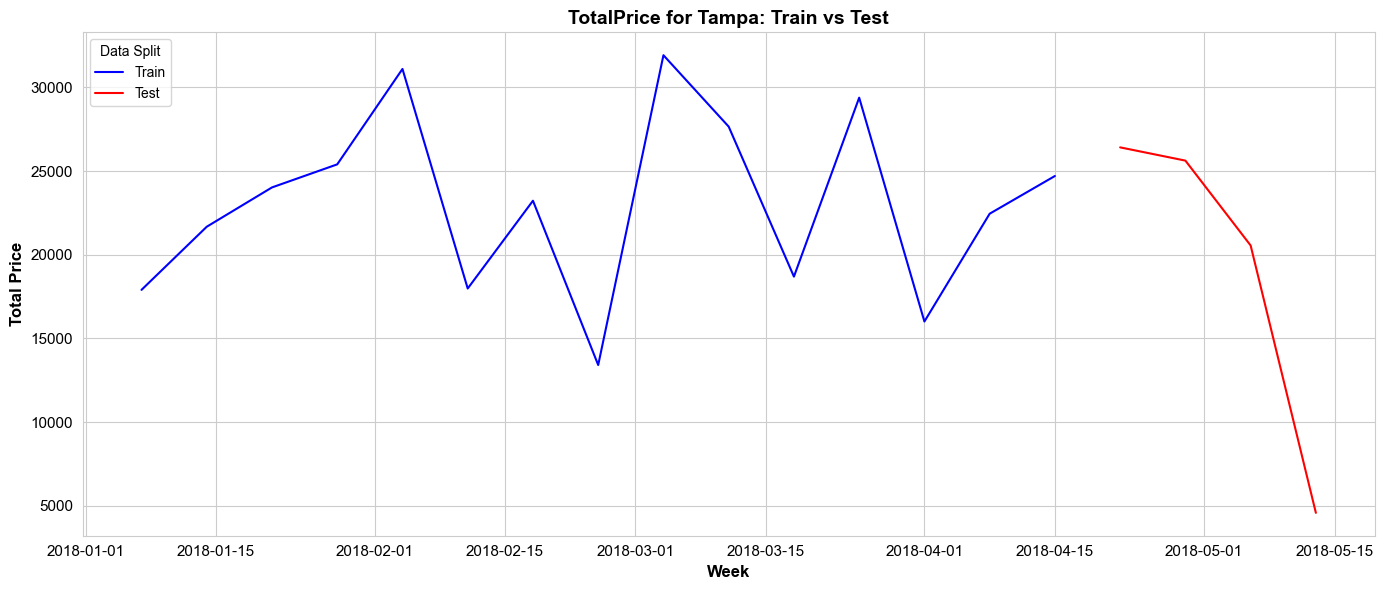

In [ ]:
plt.figure(figsize=(14, 6))
plt.plot(train.index, train['TotalPrice'], label="Train", color="blue")
plt.plot(test.index, test['TotalPrice'], label="Test", color="red")
plt.title(f"TotalPrice for {random_city}: Train vs Test")
plt.xlabel("Week")
plt.ylabel("Total Price")
plt.legend(title="Data Split", loc="upper left")
plt.grid(True)
plt.tight_layout()
plt.show()

In [124]:
from tensorflow.keras.callbacks import LearningRateScheduler

def scheduler(epoch, lr):
    if epoch < 2:
        return 0.01
    else:
        return lr * 0.99

lr_scheduler = LearningRateScheduler(scheduler)

In [125]:
from tensorflow.keras.callbacks import Callback

class CustomCallback(Callback):
    def on_epoch_end(self, epoch, logs={}):
        if logs.get('mae') < 10.0:
            print("MAE under 10.0... Stopping training")
            self.model.stop_training = True

my_callback = CustomCallback()

In [143]:
WINDOW = 10

numeric_feature_cols = [col for col in train.columns if train[col].dtype in ['float64', 'int64']]

if target in numeric_feature_cols:
    feature_cols = numeric_feature_cols
else:
    feature_cols = numeric_feature_cols + [target]

train_clean = train[feature_cols].dropna()

train_array = train_clean.values


In [144]:
windows, labels = [], []
target_idx = train_clean.columns.get_loc(target)

for i in range(len(train_array) - WINDOW):
    window = train_array[i : i + WINDOW] 
    window_flat = window.flatten()        
    label = train_array[i + WINDOW][target_idx]
    windows.append(window_flat)
    labels.append(label)

X_train = np.array(windows)
y_train = np.array(labels)

In [147]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers

def residual_block_dense(x, units, l2_strength=1e-4):
    shortcut = x

    x = layers.Dense(units, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_strength))(x)
    x = layers.Dense(units,
                     kernel_regularizer=regularizers.l2(l2_strength))(x)

    if shortcut.shape[-1] != units:
        shortcut = layers.Dense(units,
                                kernel_regularizer=regularizers.l2(l2_strength))(shortcut)

    x = layers.Add()([x, shortcut])
    x = layers.ReLU()(x)
    return x

def ResNetTabular(input_shape=(160,), l2_strength=1e-4):
    inputs = layers.Input(shape=input_shape)

    x = layers.Dense(64, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_strength))(inputs)

    x = residual_block_dense(x, 64, l2_strength)
    x = residual_block_dense(x, 32, l2_strength)

    x = layers.Dense(16, activation='relu',
                     kernel_regularizer=regularizers.l2(l2_strength))(x)

    outputs = layers.Dense(1)(x)
    model = models.Model(inputs, outputs)
    return model

model = ResNetTabular(input_shape=(50,), l2_strength=1e-4)
model.compile(loss='mse', optimizer='adam', metrics=['mae'])


print(f"Number of training samples: {X_train.shape[0]}")
print(f"Number of features per sample: {X_train.shape[1]}")
print(f"Total trainable parameters: {model.count_params()}")
print(f"Parameter-to-sample ratio: {model.count_params() / X_train.shape[0]:.2f}")

Number of training samples: 5
Number of features per sample: 50
Total trainable parameters: 17345
Parameter-to-sample ratio: 3469.00


In [148]:
model_history = model.fit(
    X_train,
    y_train,  
    epochs=200,
    callbacks=[lr_scheduler, my_callback],
    verbose=1
)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 250698848.0000 - mae: 15616.0996 - learning_rate: 0.0100
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 287625248.0000 - mae: 15879.3750 - learning_rate: 0.0100
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 1547392896.0000 - mae: 38989.3672 - learning_rate: 0.0099
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 25169202.0000 - mae: 4321.7607 - learning_rate: 0.0098
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 464115776.0000 - mae: 20991.5605 - learning_rate: 0.0097
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - loss: 445297920.0000 - mae: 20523.4277 - learning_rate: 0.0096
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 59726124.0000 - mae: 6345.7959 - learning_rate: 0.0095
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 158872288.0000 - mae: 11482.8496 - learning_rate: 0.0094
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - loss: 149340384.0000 - mae: 11065

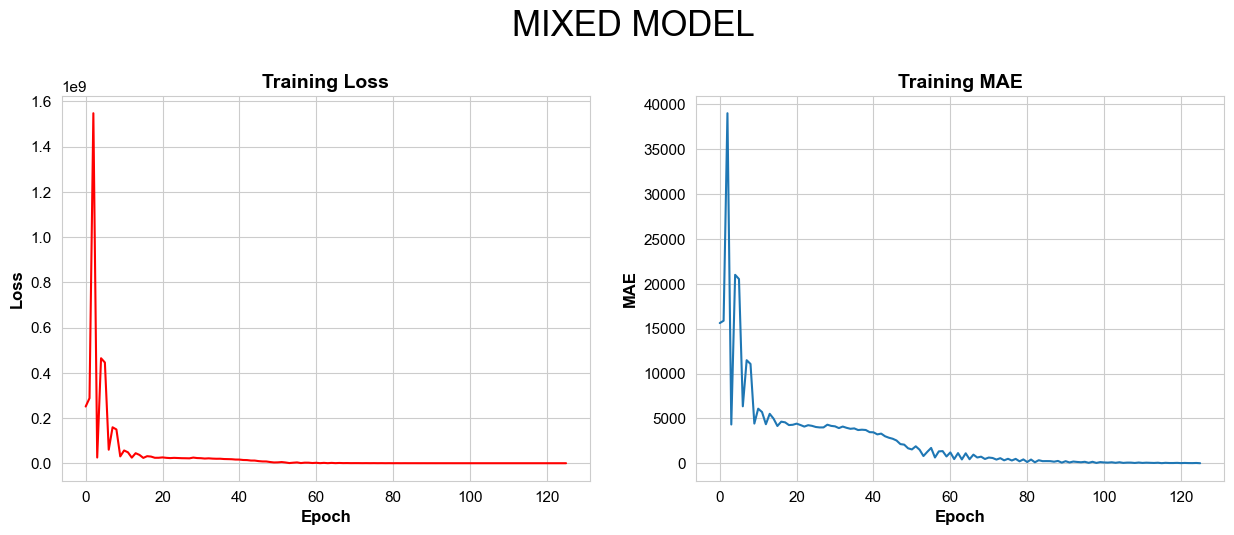

					FINAL LOSS: 92.78 | FINAL MAE: 8.77


In [149]:
plt.rcParams["figure.figsize"] = (15,5)
fig, axs = plt.subplots(1, 2)

axs[0].plot(model_history.history['loss'], color='red')
axs[0].set_xlabel('Epoch')
axs[0].set_ylabel('Loss')
axs[0].set_title('Training Loss')

axs[1].plot(model_history.history['mae'])
axs[1].set_xlabel('Epoch')
axs[1].set_ylabel('MAE')
axs[1].set_title('Training MAE')

fig.text(0.425,1, 'MIXED MODEL', {'size':25})
plt.show()

print("\t\t\t\t\tFINAL LOSS: {} | FINAL MAE: {}".format(
                                                round(model_history.history['loss'][-1], 2),
                                                 round(model_history.history['mae'][-1], 2)))

In [ ]:
if target in numeric_feature_cols:
    feature_cols = numeric_feature_cols
else:
    feature_cols = numeric_feature_cols + [target]
test_clean = test[feature_cols].dropna()

test_array = test_clean.values

test_windows, test_labels = [], []
for i in range(len(test_array) - WINDOW):
    window = test_array[i : i + WINDOW]
    window_flat = window.flatten()
    label = test_array[i + WINDOW][target_idx]
    test_windows.append(window_flat)
    test_labels.append(label)


X_test = np.array(test_windows)
y_test = np.array(test_labels)


Nombre de lignes après dropna() : 4
Les données sont insuffisantes pour créer des fenêtres avec la taille spécifiée.


In [ ]:
test_preds = model.predict(X_test).squeeze()
test_mae = np.abs(y_test - test_preds).mean()
print("Test MAE:", round(test_mae, 2))

ValueError: math domain error

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(y_test, label='Actual', color='black', linestyle='--')
plt.plot(test_preds, label='Predicted', color='red')
plt.title('Multivariate Forecast on Test Set')
plt.legend()
plt.show()

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Full series: training + test
full_train_series = train_clean[target_col].values
full_test_series = test_clean[target_col].values
combined_series = np.concatenate([full_train_series, full_test_series])

# Indices
train_len = len(full_train_series)
test_len = len(full_test_series)
context_len = WINDOW
forecast_start = train_len + context_len
prediction_index = np.arange(forecast_start, forecast_start + len(test_preds))

# Plot
plt.figure(figsize=(14, 6))

# Entire actual series
plt.plot(combined_series, label='Actual (Train + Test)', color='black')

# Predictions overlay
plt.plot(prediction_index, test_preds, label='Predicted (Test)', color='red')

# Split marker
plt.axvline(x=train_len, color='blue', linestyle='--', label='Train/Test Split')
plt.axvline(x=forecast_start, color='green', linestyle='--', label='Forecast Start')

plt.title('Forecast Across Train + Test Series')
plt.xlabel('Time Step')
plt.ylabel('Total Amount')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()